In [14]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

## 1. Load pool_threshold_sweep.py output

In [15]:
sweep_dir = config.THRESHOLD_SWEEP_DIR
combined_path = sweep_dir / "pool_vs_individual_naive_z.csv"

if combined_path.exists():
    df = pd.read_csv(combined_path)
else:
    parts = sorted(sweep_dir.glob("pool_vs_individual_naive_z_t*.csv"))
    df = pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)

print(f"thresholds present: {sorted(df['threshold'].unique())}")
print(f"rows: {len(df)}, unique genes: {df['gene'].nunique()}")
df.head()

thresholds present: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50)]
rows: 5542, unique genes: 1971


,threshold,gene,nz,ind_stage,ind_n_folds_ok,ind_fail_reasons,ind_naive_exceed,ind_naive_fdr_reject_rate,ind_raw_skew,ind_raw_kurtosis,pool_n_folds_ok,pool_fail_reasons,pool_naive_exceed,pool_naive_fdr_reject_rate,pool_raw_skew,pool_raw_kurtosis
0,10,ENSG00000007952.19,6,nbi,0,fold0:not_converged_or_explosion_or_tau2_bound...,NaN,NaN,NaN,NaN,5,NaN,0.037518,0.000000,-0.002952,0.375061
1,10,ENSG00000069764.10,6,nbi,4,fold3:not_converged_or_explosion_or_tau2_bound,0.036036,0.001802,0.087847,0.390533,5,NaN,0.037518,0.000000,-0.015301,0.385532
2,10,ENSG00000078898.8,9,nbi,3,fold0:not_converged_or_explosion_or_tau2_bound...,0.036145,0.002410,0.109271,0.543418,5,NaN,0.040404,0.000000,0.027084,0.294990
3,10,ENSG00000096395.12,8,nbi,3,fold2:not_converged_or_explosion_or_tau2_bound...,0.048077,0.002404,0.433885,2.444775,5,NaN,0.037518,0.002886,0.075332,0.788631
4,10,ENSG00000101074.5,7,nbi,2,fold0:not_converged_or_explosion_or_tau2_bound...,0.021661,0.000000,-0.046549,-0.402710,5,NaN,0.036075,0.002886,-0.001905,0.445705


## 2. Individual (nbi) vs pooled calibration vs nz
ind_* columns don't depend on threshold (same fixed-stage CV baseline reused everywhere), so dedupe to one row per gene. pool_* does depend on threshold -- for this first look, use each gene's *smallest applicable threshold* (the first group it would be pooled into), so both lines are one point per gene and directly comparable.

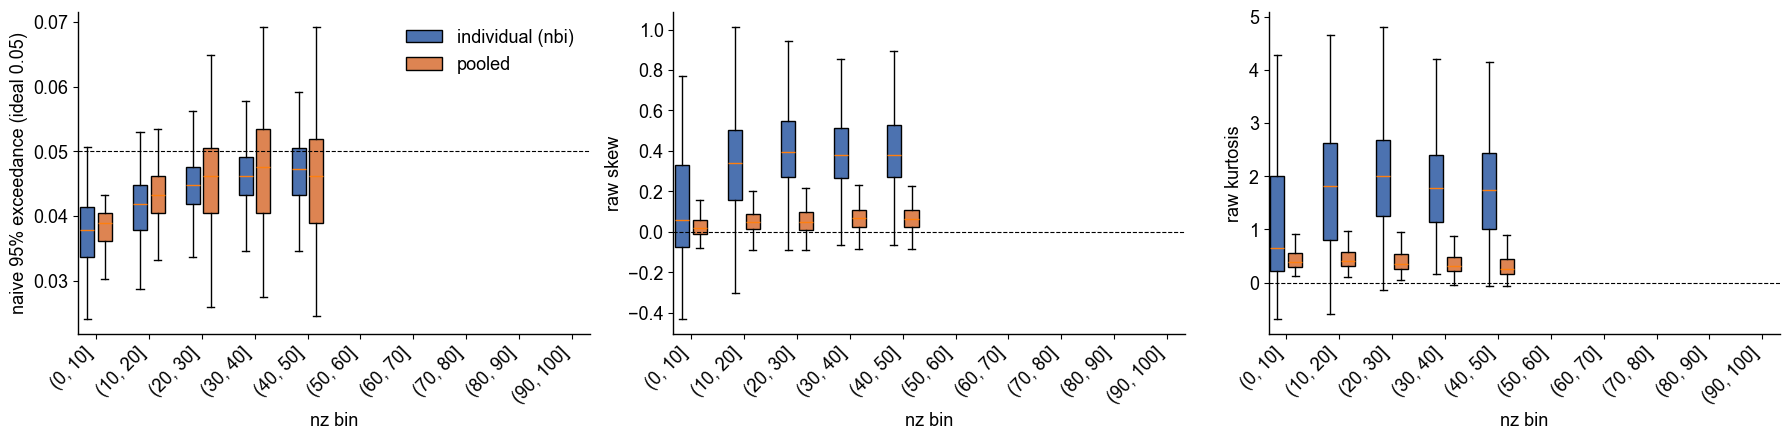

In [16]:
min_t = df.sort_values("threshold").drop_duplicates("gene", keep="first")
cols = [
    "gene", "nz", "ind_n_folds_ok", "ind_naive_exceed", "ind_raw_skew", "ind_raw_kurtosis",
    "pool_n_folds_ok", "pool_naive_exceed", "pool_raw_skew", "pool_raw_kurtosis",
]
ind = min_t[cols].copy()

nz_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
ind["nz_bin"] = pd.cut(ind["nz"], nz_bins)
bins = ind["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

panels = [
    ("ind_naive_exceed", "pool_naive_exceed", "naive 95% exceedance (ideal 0.05)", 0.05),
    ("ind_raw_skew", "pool_raw_skew", "raw skew", 0.0),
    ("ind_raw_kurtosis", "pool_raw_kurtosis", "raw kurtosis", 0.0),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (ind_col, pool_col, ylabel, ref) in zip(axes, panels):
    data_ind = [ind.loc[ind["nz_bin"] == b, ind_col].dropna() for b in bins]
    data_pool = [ind.loc[ind["nz_bin"] == b, pool_col].dropna() for b in bins]
    bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True, showfliers=False)
    bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True, showfliers=False)
    for box in bp_ind["boxes"]:
        box.set_facecolor("#4C72B0")
    for box in bp_pool["boxes"]:
        box.set_facecolor("#DD8452")
    ax.axhline(ref, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(positions_ind + 0.5)
    ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("nz bin")
axes[0].legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()

## 3. Fold-level convergence: individual vs pooled
`n_folds_ok` out of 5 -- how often each route actually converges, not just how well-calibrated the successful folds look.

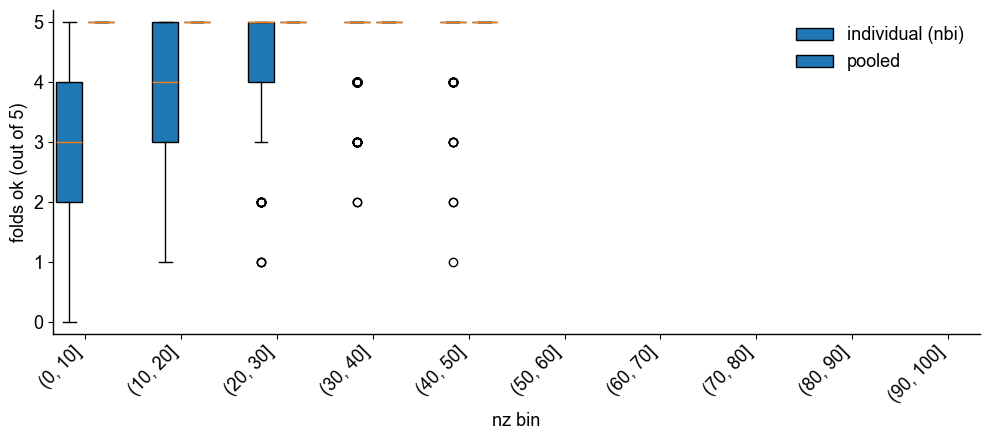

In [ ]:
bins = ind["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

data_ind = [ind.loc[ind["nz_bin"] == b, "ind_n_folds_ok"].dropna() for b in bins]
data_pool = [ind.loc[ind["nz_bin"] == b, "pool_n_folds_ok"].dropna() for b in bins]

fig, ax = plt.subplots(figsize=(10, 4.5))
bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True)
bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True)

ax.set_xticks(positions_ind + 0.5)
ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
ax.set_ylabel("folds ok (out of 5)")
ax.set_xlabel("nz bin")
ax.set_ylim(-0.2, 5.2)
ax.legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()

## 4. Pooled vs individual: per-gene distortion score
distortion = |raw_skew| + |raw_kurtosis| (lower is better-calibrated). Compare individual vs the pooled fit each gene actually received at each threshold.

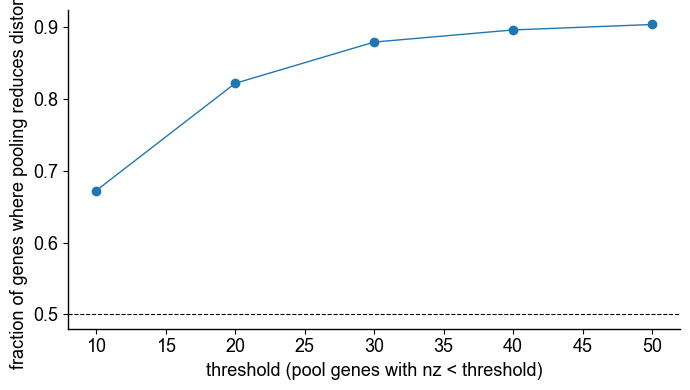

In [11]:
df["ind_distortion"] = df["ind_raw_skew"].abs() + df["ind_raw_kurtosis"].abs()
df["pool_distortion"] = df["pool_raw_skew"].abs() + df["pool_raw_kurtosis"].abs()
df["pool_wins"] = df["pool_distortion"] < df["ind_distortion"]
# individual completely failed -> pooling wins by default (no individual Z to compare against)
df.loc[df["ind_n_folds_ok"] == 0, "pool_wins"] = df["pool_n_folds_ok"] > 0

win_rate = df.groupby("threshold")["pool_wins"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(win_rate.index, win_rate.values, marker="o")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("threshold (pool genes with nz < threshold)")
ax.set_ylabel("fraction of genes where pooling reduces distortion")
plt.tight_layout()
plt.show()

## 5. Same, restricted to genes near the threshold boundary
Genes just below a given threshold are the ones whose route assignment is actually being decided by that threshold -- their outcome matters more than genes deep inside the pool (nz << threshold) or comfortably above it.

In [ ]:
MARGIN = 10
near_boundary = df[df["nz"] >= df["threshold"] - MARGIN]
win_rate_boundary = near_boundary.groupby("threshold")["pool_wins"].mean()
n_boundary = near_boundary.groupby("threshold")["gene"].size()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(win_rate_boundary.index, win_rate_boundary.values, marker="o", label=f"nz in [threshold-{MARGIN}, threshold)")
ax.plot(win_rate.index, win_rate.values, marker="o", alpha=0.4, label="all pooled genes")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("threshold")
ax.set_ylabel("fraction of genes where pooling reduces distortion")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
print(n_boundary)

## 6. Notes
- Re-run this notebook as `pool_threshold_sweep.py` finishes more thresholds (it caches per-threshold, safe to re-run anytime).
- `naive_*` / `raw_*` fields are pre-SHASH RQR diagnostics -- SHASH correction is applied later, at scoring time, not for this route-selection decision.
- `MARGIN` in section 5 is a starting guess; adjust and re-run to see how sensitive the crossover point is.